# NIDS - Exploratory Data Analysis
## UNSW-NB15 Dataset

Combine training and testing sets for comprehensive EDA.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

TRAIN_PATH = '../dataset/UNSW_NB15_training-set.csv'
TEST_PATH = '../dataset/UNSW_NB15_testing-set.csv'

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Combined shape: {df.shape}')

Train shape: (82332, 45)
Test shape: (175341, 45)
Combined shape: (257673, 45)


---
## 1. Basic Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  si

In [5]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,257673.000000,2.576730e+05,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,72811.823858,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,84.754957,7.060869e+07,...,5.238271,4.032677,8.322964,0.012819,0.012850,0.132005,6.800045,9.121049,0.014274,0.639077
std,48929.917641,5.974305,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,112.762131,1.857313e+08,...,8.160822,5.831515,11.120754,0.116091,0.116421,0.681854,8.396266,10.874752,0.118618,0.480269
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,32210.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,0.000000,1.231800e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,64419.000000,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,29.000000,7.439423e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,110923.000000,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,252.000000,8.000000e+07,...,4.000000,3.000000,8.000000,0.000000,0.000000,0.000000,8.000000,11.000000,0.000000,1.000000
max,175341.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,59.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


---
## 2. Missing Values

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')
missing

Columns with missing values: 0


Series([], dtype: int64)

In [7]:
# Check for '-' in service column
dash_count = (df['service'] == '-').sum()
print(f'"-" values in service column: {dash_count} ({dash_count/len(df)*100:.2f}%)')

"-" values in service column: 141321 (54.85%)


---
## 3. Class Distribution (Label)

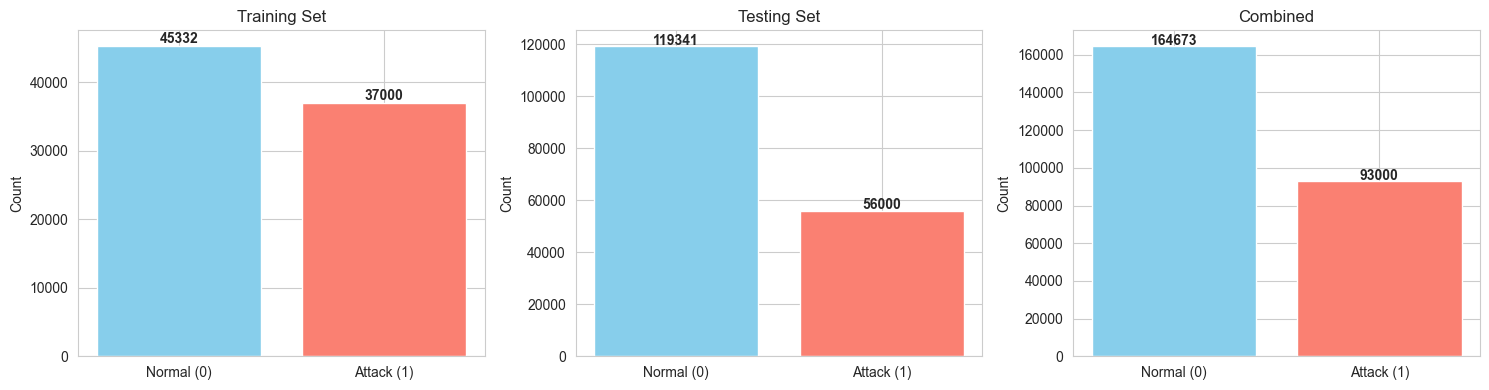

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in zip(axes, [train_df, test_df, df], ['Training Set', 'Testing Set', 'Combined']):
    counts = data['label'].value_counts()
    ax.bar(['Normal (0)', 'Attack (1)'], counts.values, color=['skyblue', 'salmon'])
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
print('Training set label ratio:')
print(train_df['label'].value_counts(normalize=True).to_frame('ratio').T)
print()
print('Testing set label ratio:')
print(test_df['label'].value_counts(normalize=True).to_frame('ratio').T)

Training set label ratio:
label       1       0
ratio  0.5506  0.4494

Testing set label ratio:
label         1         0
ratio  0.680622  0.319378


---
## 4. Categorical Features

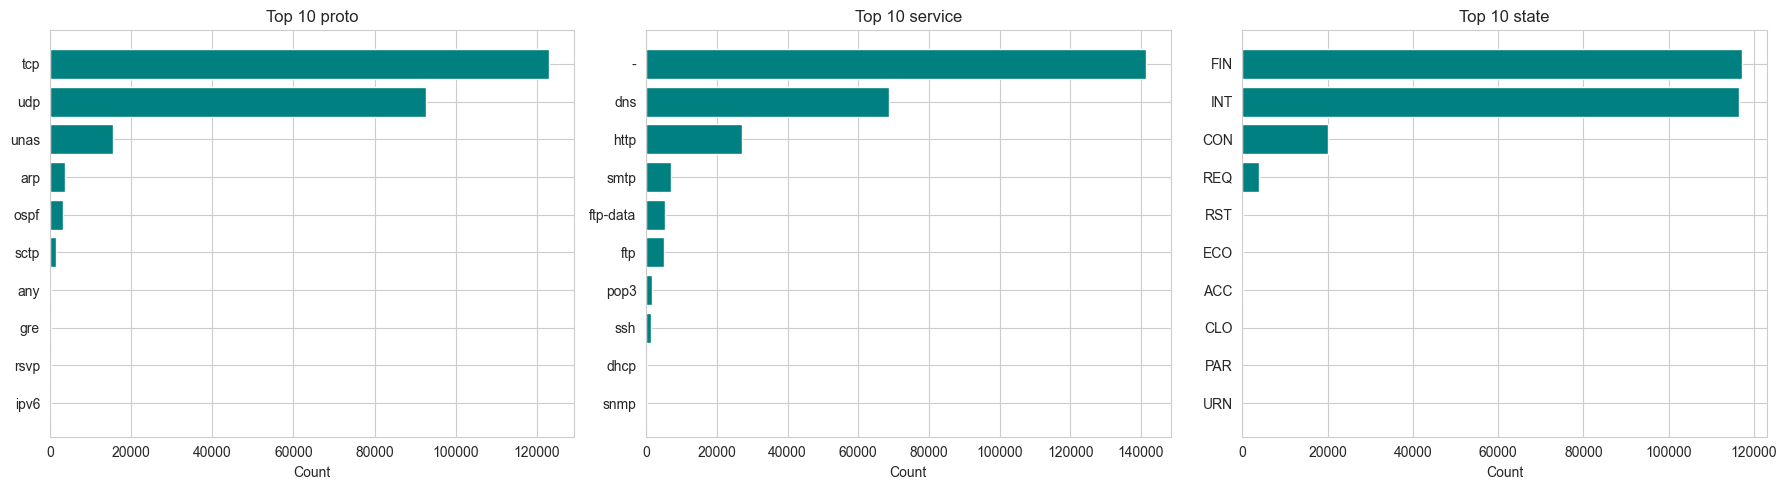

In [10]:
cat_cols = ['proto', 'service', 'state']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts().head(10)
    ax.barh(counts.index[::-1], counts.values[::-1], color='teal')
    ax.set_title(f'Top 10 {col}')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

In [11]:
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().head(5).to_string())
    print()

proto: 133 unique values
proto
tcp     123041
udp      92701
unas     15599
arp       3846
ospf      3271

service: 13 unique values
service
-           141321
dns          68661
http         27011
smtp          6909
ftp-data      5391

state: 11 unique values
state
FIN    117164
INT    116438
CON     20134
REQ      3833
RST        84



---
## 5. Attack Category Distribution

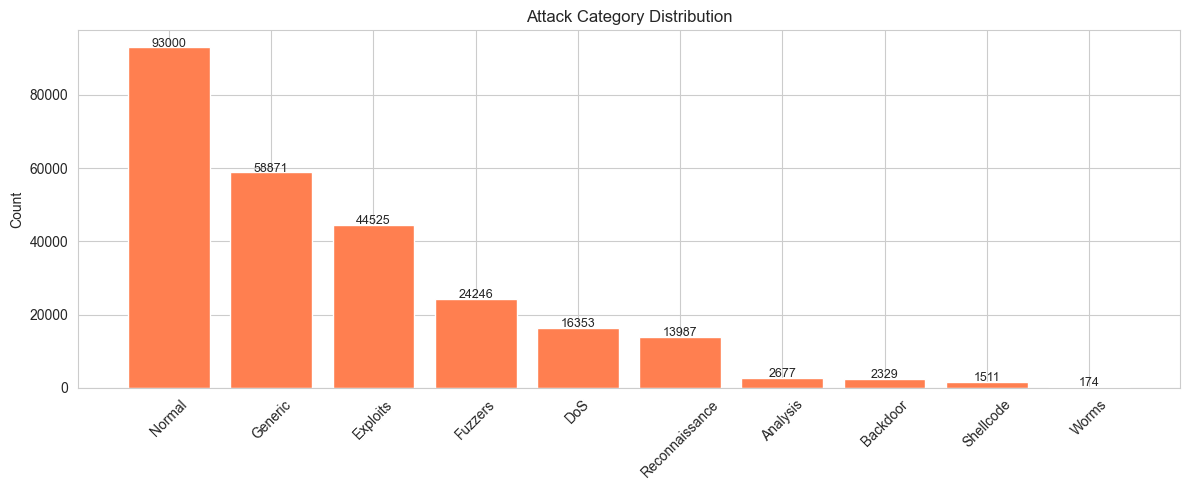

In [12]:
attack_counts = df['attack_cat'].value_counts()
plt.figure(figsize=(12, 5))
bars = plt.bar(attack_counts.index, attack_counts.values, color='coral')
plt.title('Attack Category Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             int(bar.get_height()), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Numerical Features Distribution (by Class)

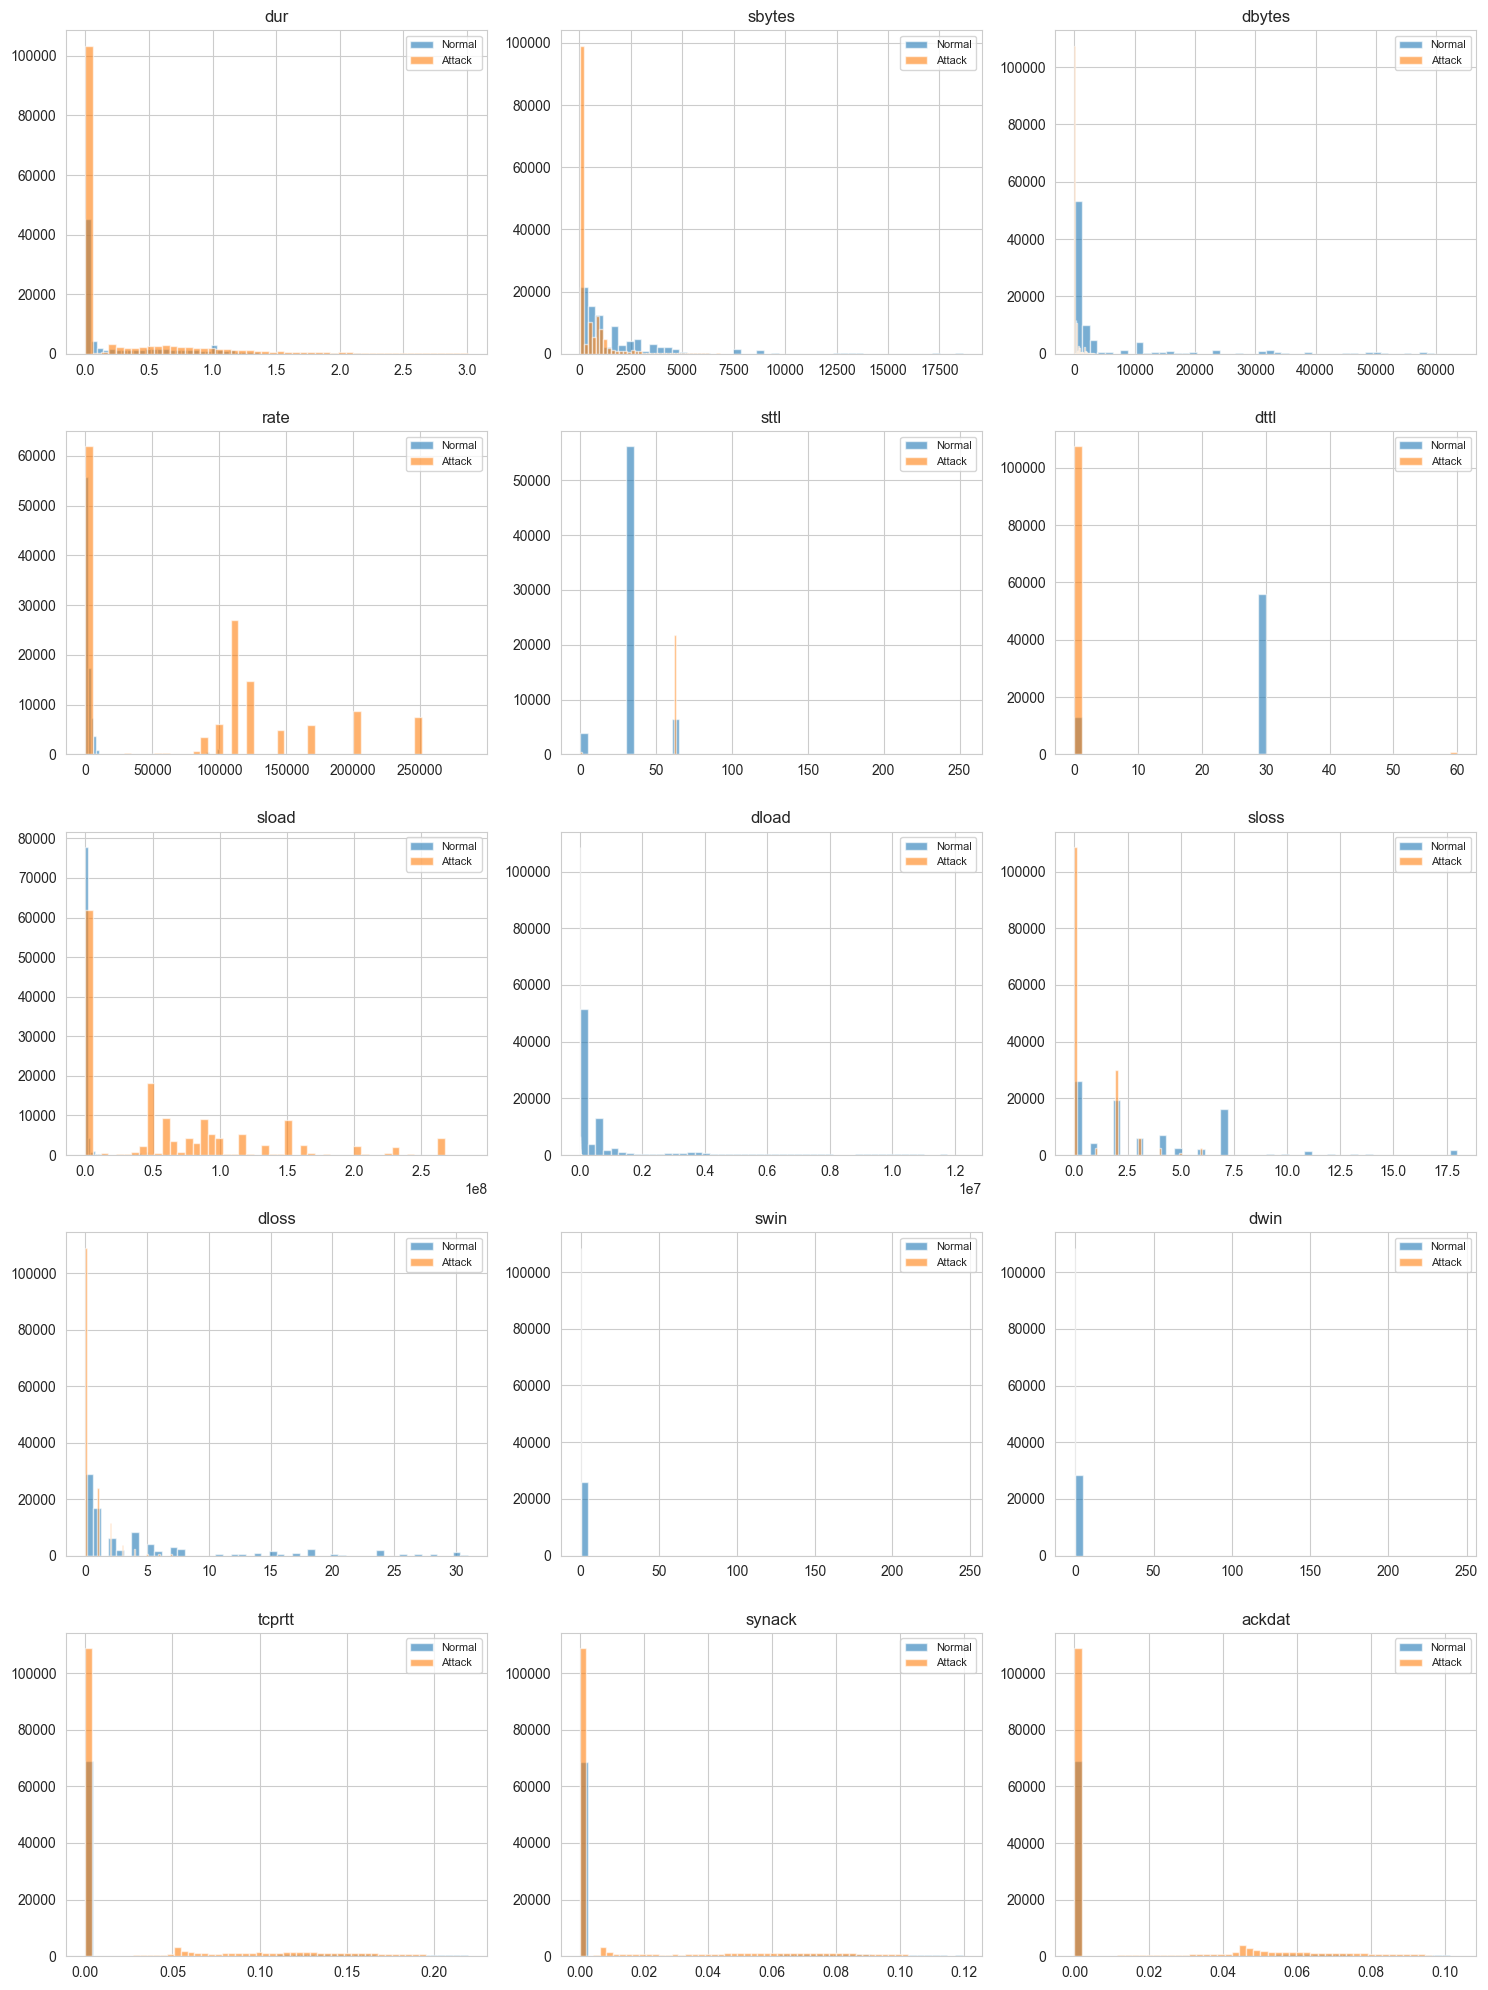

In [13]:
num_cols = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload',
            'sloss', 'dloss', 'swin', 'dwin', 'tcprtt', 'synack', 'ackdat']

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label in [0, 1]:
        subset = df[df['label'] == label][col].dropna()
        subset = subset[subset < subset.quantile(0.95)]
        axes[i].hist(subset, bins=50, alpha=0.6, label=f'{"Normal" if label==0 else "Attack"}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 7. Correlation Matrix (Required Features)

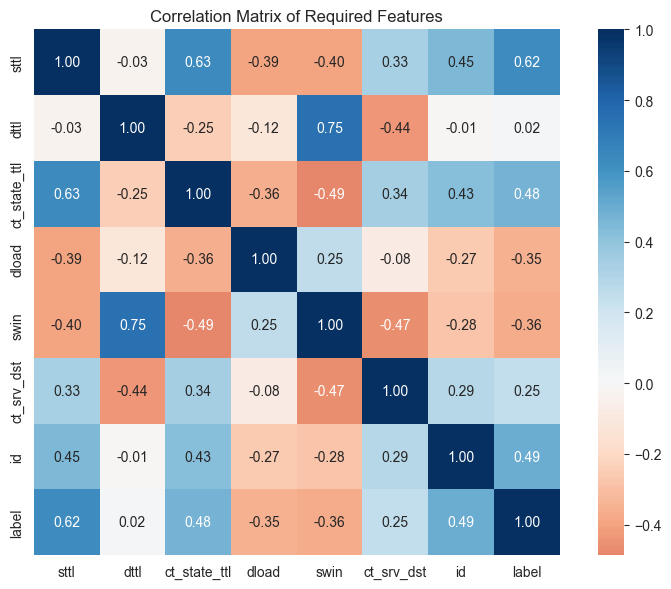

In [14]:
required = ['sttl', 'dttl', 'ct_state_ttl', 'dload', 'swin', 'ct_srv_dst', 'id', 'label']
corr = df[required].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0, square=True)
plt.title('Correlation Matrix of Required Features')
plt.tight_layout()
plt.show()

---
## 8. Boxplots of Key Features vs Label

C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\4006776229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette=['skyblue', 'salmon'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\4006776229.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Normal', 'Attack'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\4006776229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette=['skyblue', 'salmon'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\4006776229.py:9: UserWarning: set_ticklabel

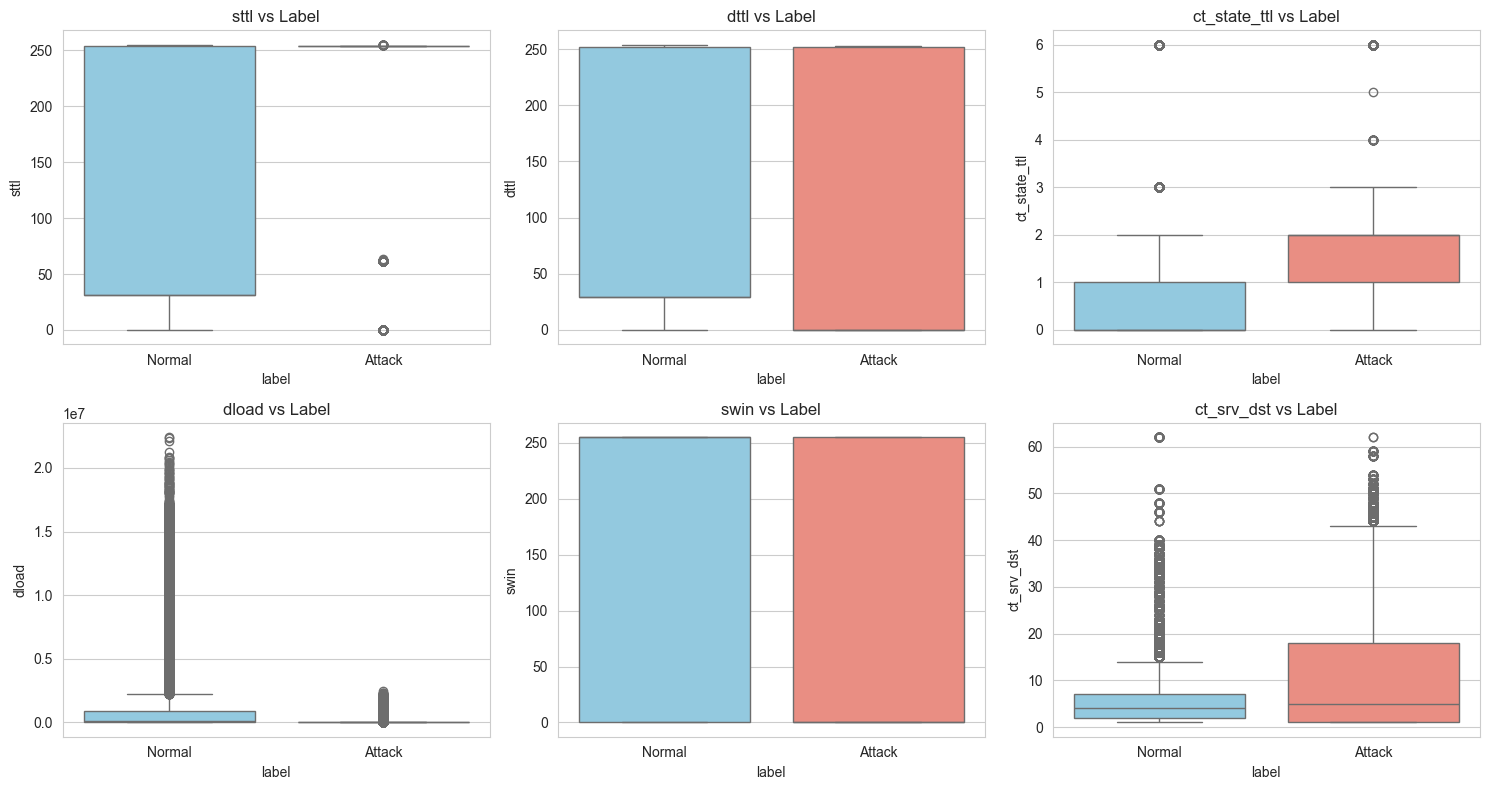

In [15]:
key_feats = ['sttl', 'dttl', 'ct_state_ttl', 'dload', 'swin', 'ct_srv_dst']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_feats):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i], palette=['skyblue', 'salmon'])
    axes[i].set_title(f'{col} vs Label')
    axes[i].set_xticklabels(['Normal', 'Attack'])

plt.tight_layout()
plt.show()

---
## 9. Cleaning Impact

In [16]:
before = len(df)
df_clean = df.copy()
df_clean['service'] = df_clean['service'].replace('-', np.nan)
df_clean = df_clean.dropna()
after = len(df_clean)
removed = before - after
print(f'Before cleaning: {before} rows')
print(f'After cleaning:  {after} rows')
print(f'Removed:         {removed} rows ({removed/before*100:.2f}%)')

Before cleaning: 257673 rows
After cleaning:  116352 rows
Removed:         141321 rows (54.85%)


---
## 10. Feature Importance (ETC Top Features)

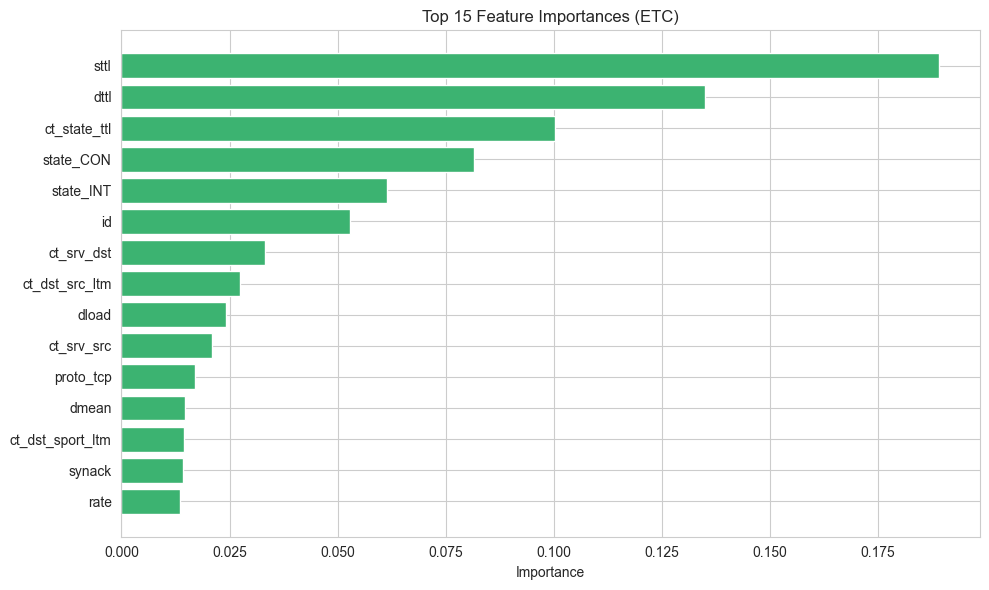

Required feature presence in top 8:
  1. sttl: 0.1892 <<<
  2. dttl: 0.1351 <<<
  3. ct_state_ttl: 0.1003 <<<
  4. state_CON: 0.0817 <<<
  5. state_INT: 0.0615 <<<
  6. id: 0.0528 <<<
  7. ct_srv_dst: 0.0333 <<<
  8. ct_dst_src_ltm: 0.0274


In [17]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import MinMaxScaler

df_encoded = pd.get_dummies(df_clean, columns=['proto', 'service', 'state'])
X = df_encoded.drop(columns=['attack_cat', 'label'])
y = df_encoded['label'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

etc = ExtraTreesClassifier(random_state=42, n_jobs=-1)
etc.fit(X_scaled, y)

importances = sorted(
    zip(X.columns, etc.feature_importances_),
    key=lambda x: x[1],
    reverse=True
)[:15]

names, scores = zip(*importances)

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(names)), scores, color='mediumseagreen')
plt.yticks(range(len(names)), names)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (ETC)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Required feature presence in top 8:')
required_set = {'sttl', 'dttl', 'ct_state_ttl', 'dload', 'swin', 'ct_srv_dst', 'id'}
for i, (name, score) in enumerate(importances[:8]):
    mark = ' <<<' if name in required_set or name.startswith('state_') else ''
    print(f'  {i+1}. {name}: {score:.4f}{mark}')

---
## 11. SMOTE Effect Visualization

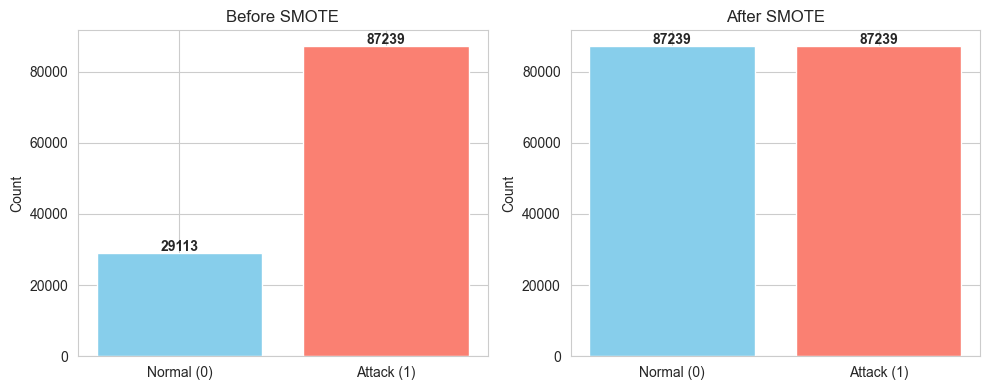

Before SMOTE: {np.int64(0): 29113, np.int64(1): 87239}
After SMOTE:  {np.int64(0): 87239, np.int64(1): 87239}


In [18]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, title in zip(axes, [y, y_res], ['Before SMOTE', 'After SMOTE']):
    counts = Counter(data)
    ax.bar(['Normal (0)', 'Attack (1)'], [counts[0], counts[1]],
           color=['skyblue', 'salmon'])
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Before SMOTE: {dict(Counter(y))}')
print(f'After SMOTE:  {dict(Counter(y_res))}')

---
## 12. Key Insights Summary

In [19]:
print('='*60)
print('EDA SUMMARY')
print('='*60)
print(f'Total records (combined): {len(df):,}')
print(f'Training records:         {len(train_df):,}')
print(f'Testing records:          {len(test_df):,}')
print(f'Features (numeric):       {len(num_cols)}')
print(f'Features (categorical):   {len(cat_cols)}')
print()
print('Class distribution (training):')
for k, v in train_df['label'].value_counts().items():
    print(f'  {"Normal" if k==0 else "Attack"}: {v:,} ({v/len(train_df)*100:.2f}%)')
print()
print('Cleaning: service column has', end=' ')
dash = (df['service'] == '-').sum()
print(f'{dash} ({dash/len(df)*100:.2f}%) rows with "-" (replaced and dropped)')
print()
print('Top 5 features by ETC importance:')
for i, (n, s) in enumerate(importances[:5]):
    print(f'  {i+1}. {n}: {s:.4f}')
print()
print(f'After SMOTE: 1:1 ratio with {len(y_res):,} samples')

EDA SUMMARY
Total records (combined): 257,673
Training records:         82,332
Testing records:          175,341
Features (numeric):       15
Features (categorical):   3

Class distribution (training):
  Attack: 45,332 (55.06%)
  Normal: 37,000 (44.94%)

Cleaning: service column has 141321 (54.85%) rows with "-" (replaced and dropped)

Top 5 features by ETC importance:
  1. sttl: 0.1892
  2. dttl: 0.1351
  3. ct_state_ttl: 0.1003
  4. state_CON: 0.0817
  5. state_INT: 0.0615

After SMOTE: 1:1 ratio with 174,478 samples
